# Calculate and plot MOC strength over time 

## load data locally

Figure S6

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4

In [2]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
            'p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
            'CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


In [3]:
# # import data loading function
# import sys
# if '/tigress/wenchang/wython' not in sys.path:
#     sys.path.append('/tigress/wenchang/wython')
    
# from misc.modelout import get_modelout_data, get_modelout_files

import sys
if '/tigress/wenchang/wython/' not in sys.path:
    sys.path.append('/tigress/wenchang/wython/')
    
from modelout.modelout import get_modelout_data, get_modelout_files

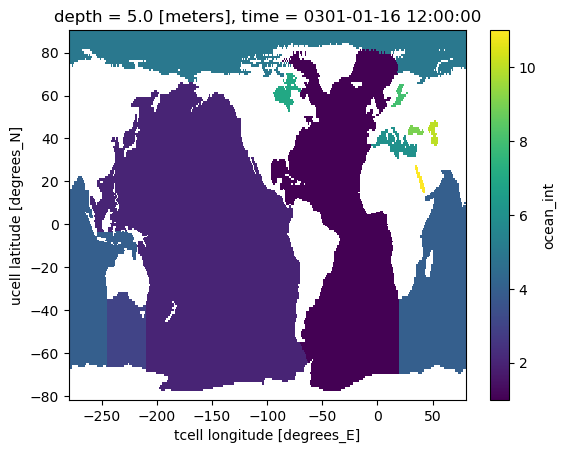

In [4]:
mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
mask.plot()

In [5]:
def get_AMOC_PMOC_efficient(da):
    # get the mask
    mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
    
    da_masked_atlantic = da.sel(lat=slice(30,60)).where(mask==1)
    da_masked_IP = da.sel(lat=slice(30,60)).where((mask == 2) | (mask == 3) | (mask == 4))
    
    AMOC = da_masked_atlantic.sum('lon').cumsum('depth')
    PMOC = da_masked_IP.sum('lon').cumsum('depth')
    
    # get a single number for strength at each time
    AMOC_ts = AMOC.sel(depth=slice(500,None)).max(('lat','depth'))
    PMOC_ts = PMOC.sel(depth=slice(500,None)).max(('lat','depth'))
    
    return AMOC_ts, PMOC_ts

def get_SMOC_efficient(da):
    # get the mask
    mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
    
    da_masked_SO = da.sel(lat=slice(-60,-20))
    
    SMOC = da_masked_SO.sum('lon').cumsum('depth')
    
    # get a single number for strength at each time
    SMOC_ts = SMOC.sel(depth=slice(500,None)).min(('lat','depth'))
    
    return SMOC_ts

# load data and get MOC

In [6]:
models = ['CM2.1p1','FLOR']
func = lambda x: x.load()
funcname = 'output'

for model in models:
    exps, extension = get_experiment_names(model)
    if model == 'FLOR': dsname = 'ocean'
    elif model == 'CM2.1p1': dsname = 'ocean_month'

    for iexp in range(np.size(exps)):
        experiment = f'{exps[iexp]}_{extension}'

        if exps[iexp] == 'CTL1860_newdiag' or exps[iexp] == 'CTL1860': # if it's a control experiment,
            n_yrs = 2000 # stop at 2000 years
        else:
            filelist = get_modelout_files(model, experiment, dsname='ocean', ens=None)
            n_yrs = np.shape(filelist)[1]

        #n_yrs = 10 # for testing
        data_shape = (n_yrs,) 

        # check if the MOC file exists
        import os
        file_path = f'./processed_data/MOC_annavg_ts_Atlantic_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(101,100+n_yrs)
        print(file_path)
        if os.path.exists(file_path):
            print(f'file exists for {model}_{exps[iexp]}')
            continue
    
        # Create an empty DataArray filled with NaNs
        AMOC_da = xr.DataArray(
            np.full(data_shape, np.nan),  # Fill with NaNs
            dims=["year"],  # Define the dimension
            coords={"year": np.arange(101,101+n_yrs,1)},  # Assign years as the coordinate for the time dimension
            name="AMOC [Sv]", # Optional name for the data array
        )
    
        PMOC_da = AMOC_da.copy()  # Create a copy of the DataArray
        PMOC_da.name = "PMOC [Sv]"  # Rename the DataArray
    
        SMOC_da = AMOC_da.copy()  # Create a copy of the DataArray
        SMOC_da.name = "SMOC [Sv]"  # Rename the DataArray
    
        for iyr in range(n_yrs): # for each year
            year = iyr + 101
            
            # load data
            da_in = get_modelout_data(daname='ty_trans', model=model, expname=experiment, 
                                           years=[year], 
                                    func=func, funcname=funcname, dsname=dsname, savedata=False)
            # get MOC for 12 months
            da_in = da_in.rename({'xt_ocean': 'lon', 'yu_ocean': 'lat','st_ocean': 'depth'})
            
            AMOC, PMOC = get_AMOC_PMOC_efficient(da_in)
            SMOC = get_SMOC_efficient(da_in)
            
            AMOC = AMOC.mean('time') # annual average
            PMOC = PMOC.mean('time')
            SMOC = SMOC.mean('time')
    
            # save annual average in data array
            AMOC_da.loc[{"year": year}] = AMOC
            PMOC_da.loc[{"year": year}] = PMOC
            SMOC_da.loc[{"year": year}] = SMOC
    
        # save populated AMOC, PMOC, SMOC arrays
        AMOC_filename = f'./processed_data/MOC_annavg_ts_Atlantic_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(AMOC_da.year.values[0],AMOC_da.year.values[-1])
        print(f'{AMOC_filename}')
        PMOC_filename = f'./processed_data/MOC_annavg_ts_IndoPacific_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(PMOC_da.year.values[0],PMOC_da.year.values[-1])
        print(f'{PMOC_filename}')
        SMOC_filename = f'./processed_data/MOC_annavg_ts_SouthernOcean_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(SMOC_da.year.values[0],SMOC_da.year.values[-1])
        print('saving AMOC...')
        AMOC_da.to_netcdf(AMOC_filename)
        print('saving PMOC...')
        PMOC_da.to_netcdf(PMOC_filename)
        print('saving SMOC...')
        SMOC_da.to_netcdf(SMOC_filename)

./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_p6pctSolar.0101-0310.nc
file exists for CM2.1p1_CTL1860_p6pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_p4pctSolar.0101-2000.nc
file exists for CM2.1p1_CTL1860_p4pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_p2pctSolar.0101-1100.nc
file exists for CM2.1p1_CTL1860_p2pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_p1pctSolar.0101-0300.nc
file exists for CM2.1p1_CTL1860_p1pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860.0101-2100.nc
file exists for CM2.1p1_CTL1860
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_m1pctSolar.0101-0300.nc
file exists for CM2.1p1_CTL1860_m1pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_m2pctSolar.0101-1100.nc
file exists for CM2.1p1_CTL1860_m2pctSolar
./processed_data/MOC_annavg_ts_Atlantic_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc
file exists for CM2.1p1_CTL1860_m4pctSolar
./processed_data/MOC_annavg_ts_Atlanti

# plot MOC for all experiments by basin

In [7]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
            'p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
            'CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


In [8]:
import os

def find_files_starting_with(directory, start_string):
    files = [
        file for file in os.listdir(directory)
        if os.path.isfile(os.path.join(directory, file)) and file.startswith(start_string)
    ]
    if np.size(files) > 1:
        #print('Multiple files found')
        files = files[0]
    elif np.size(files) < 1:
        #print('No files found')
        files = []
    else:
        files = files[0]
    return files

In [9]:
def get_color_label(experiment):
    if 'from' in experiment: color, label = '', 'ens'
    elif 'p6' in experiment: color, label = 'darkred', '+6%'
    elif 'p4' in experiment: color, label = 'red', '+4%'
    elif 'p2' in experiment: color, label = 'orange', '+2%'
    elif 'p1' in experiment: color, label = 'gold', '+1%'
    elif 'm1' in experiment: color, label = 'cyan', '-1%'
    elif 'm2' in experiment: color, label = 'dodgerblue', '-2%'
    elif 'm4' in experiment: color, label = 'blue', '-4%'
    elif 'm6' in experiment: color, label = 'darkblue', '-6%'
    else: color, label = 'grey', 'CTRL'

    return color, label

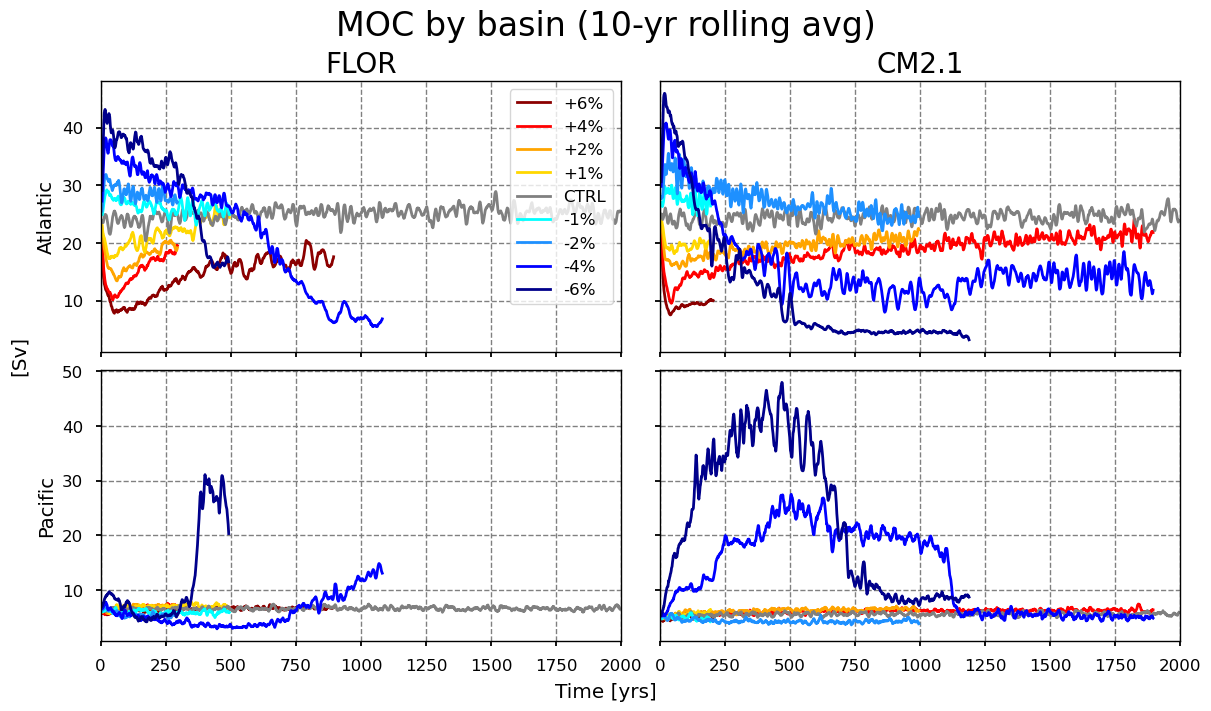

In [86]:
models = ['FLOR','CM2.1p1']
dir_in = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/'
basins = ['Atlantic','IndoPacific']#,'SouthernOcean']

window = 10 # rolling avg (years)

plt.style.use('../func/paper.mplstyle')

fig, ax = plt.subplots(np.size(basins), 2, figsize=(12,7), sharey = 'row', sharex=True)

for imodel in range(2):
    model = models[imodel]
    
    exps, extension = get_experiment_names(model)

    for ib in range(np.size(basins)): # for each basin
        
        basin = basins[ib]
        ax[ib,imodel].set_ylabel(basin)
            
        for iexp in range(np.size(exps)): # for each experiment
            
            experiment = exps[iexp]
            
            start_string = f'MOC_annavg_ts_{basin}_{model}_{experiment}.' # find the file name based on the basin, experiment and model
            file_in = find_files_starting_with(dir_in, start_string)
            if np.size(file_in) == 0: # if no file exists
                continue

            MOC = xr.open_dataarray(f'{dir_in}/{file_in}') # open the file

            color, label = get_color_label(experiment)
            ax[ib,imodel].plot(MOC.rolling(year=window,center=True).mean('year'),color=color,label=label) # plot timeseries

    fig.suptitle(f'MOC by basin ({window}-yr rolling avg)')
    fig.supylabel('[Sv]')
    fig.supxlabel('Time [yrs]')
    for axis in ax.flatten():
        axis.grid('--')

ax[0,0].legend()
ax[0,0].set_xlim(0,2000)
ax[0,0].set_title('FLOR')
ax[0,1].set_title('CM2.1')
ax[1,0].set_ylabel('Pacific')
ax[0,1].set_ylabel('')
ax[1,1].set_ylabel('')

#fig.savefig('FigureS6.pdf')

# Load ty_trans data for zonal view of MOC

In [12]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


In [23]:
def get_PMOC(da):
    # get the mask
    mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
    
    #da_masked_atlantic = da.sel(lat=slice(30,60)).where(mask==1)
    #da_masked_IP = da.sel(lat=slice(30,60)).where((mask == 2) | (mask == 3) | (mask == 4))
    da_masked_IP = da.where((mask == 2) | (mask == 3) | (mask == 4))
    
    #AMOC = da_masked_atlantic.sum('lon').cumsum('depth')
    PMOC = da_masked_IP.sum('lon').cumsum('depth')
    
    # get a single number for strength at each time
    #AMOC_ts = AMOC.sel(depth=slice(500,None)).max(('lat','depth'))
    #PMOC_ts = PMOC.sel(depth=slice(500,None)).max(('lat','depth'))
    
    return PMOC #AMOC, PMOC

In [47]:
models = ['FLOR']#['CM2.1p1','FLOR']
func = lambda x: x.load()
funcname = 'output'

start_year = 501 #101
n_yrs = 97

for model in models:
    exps, extension = get_experiment_names(model)
    if model == 'FLOR': dsname = 'ocean'
    elif model == 'CM2.1p1': dsname = 'ocean_month'

    for iexp in range(np.size(exps)):
        experiment = f'{exps[iexp]}_{extension}'

        # if exps[iexp] == 'CTL1860_newdiag' or exps[iexp] == 'CTL1860': # if it's a control experiment,
        #     n_yrs = 2000 # stop at 2000 years
        # else:
        filelist = get_modelout_files(model, experiment, dsname='ocean', ens=None)
        #n_yrs = np.shape(filelist)[1]
        #n_yrs = 10
        
        # check if the MOC file exists
        import os
        file_path = f'./processed_data/MOC_zonal_annavg_IndoPacific_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(start_year,start_year-1+n_yrs)
        print(file_path)
        if os.path.exists(file_path):
            print(f'file exists for {model}_{exps[iexp]}')
            continue
    
        for iyr in range(n_yrs): # for each year
            year = iyr + start_year
            
            # load data
            da_in = get_modelout_data(daname='ty_trans', model=model, expname=experiment, 
                                           years=[year], 
                                    func=func, funcname=funcname, dsname=dsname, savedata=False)
            # get MOC for 12 months
            da_in = da_in.rename({'xt_ocean': 'lon', 'yu_ocean': 'lat','st_ocean': 'depth'})
            data_shape = np.shape(da_in)
            
            PMOC = get_PMOC(da_in)
            PMOC = PMOC.mean('time') # annual average
            
            if iyr == 0:
                # Create an empty DataArray filled with NaNs
                PMOC_da = xr.DataArray(
                    np.full((n_yrs, da_in.depth.size, da_in.lat.size), 
                            np.nan),  # Fill with NaNs
                    dims=["year","depth","lat"],  # Define the dimension
                    coords={"year": np.arange(start_year,start_year+n_yrs,1),
                           "lat": da_in.lat, 
                           "depth": da_in.depth},  # Assign years as the coordinate for the time dimension
                    name="PMOC [Sv]", # Optional name for the data array
                )

            # save annual average in data array
            PMOC_da.loc[{"year": year}] = PMOC
            
        # save populated PMOC array
        PMOC_filename = f'./processed_data/MOC_zonal_annavg_IndoPacific_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                      .format(PMOC_da.year.values[0],PMOC_da.year.values[-1])
        print(f'{PMOC_filename}')
        print('saving PMOC...')
        PMOC_da.to_netcdf(PMOC_filename)

./processed_data/MOC_annavg_ts_Atlantic_FLOR_m6p0sol_CTL1860.0501-0597.nc
ifiles:
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05010101.ocean.nc
  to
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05010101.ocean.nc
years = [501]
[001 of 001]: /tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05010101.ocean.nc ty_trans output


/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/xarray/coding/times.py:1005: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


concatenating over time...
ifiles:
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05020101.ocean.nc
  to
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05020101.ocean.nc
years = [502]
[001 of 001]: /tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05020101.ocean.nc ty_trans output


/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/xarray/coding/times.py:1005: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


concatenating over time...
ifiles:
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05030101.ocean.nc
  to
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05030101.ocean.nc
years = [503]
[001 of 001]: /tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05030101.ocean.nc ty_trans output


...

concatenating over time...
ifiles:
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05960101.ocean.nc
  to
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05960101.ocean.nc
years = [596]
[001 of 001]: /tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05960101.ocean.nc ty_trans output


/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/xarray/coding/times.py:1005: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


concatenating over time...
ifiles:
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05970101.ocean.nc
  to
/tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05970101.ocean.nc
years = [597]
[001 of 001]: /tigress/wenchang/MODEL_OUT/FLOR/m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE/POSTP/05970101.ocean.nc ty_trans output


/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/xarray/coding/times.py:1005: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


concatenating over time...
./processed_data/MOC_zonal_annavg_IndoPacific_FLOR_m6p0sol_CTL1860.0501-0597.nc
saving PMOC...


# Plot zonal view of MOC

In [6]:
# load data
da_FLOR = xr.open_dataarray('./processed_data/MOC_zonal_annavg_IndoPacific_FLOR_m6p0sol_CTL1860.0501-0597.nc')
da_CM21 = xr.open_dataarray('./processed_data/MOC_zonal_annavg_IndoPacific_CM2.1p1_CTL1860_m6pctSolar.0501-0600.nc')

# Plot with timeseries

In [73]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
            'p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
            'CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


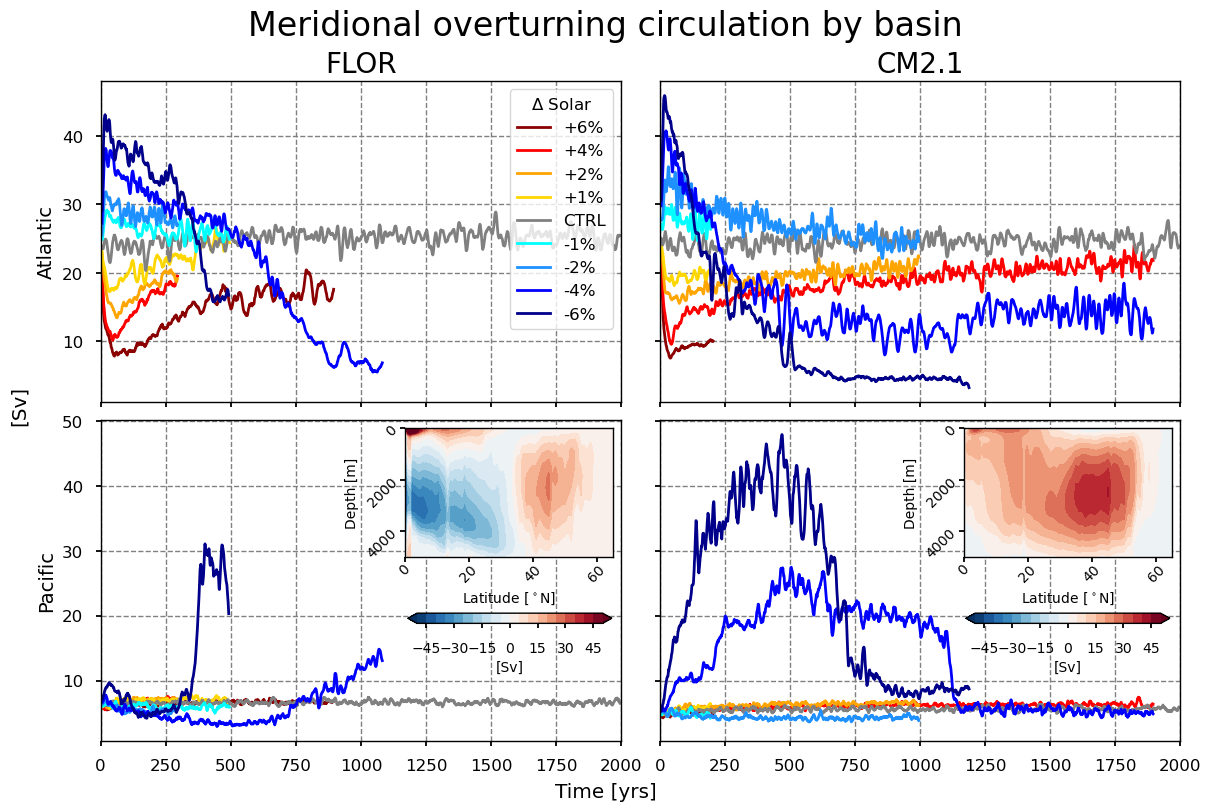

In [114]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

models = ['FLOR','CM2.1p1']
dir_in = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/'
basins = ['Atlantic','IndoPacific']#,'SouthernOcean']

window = 10 # rolling avg (years)

plt.style.use('../func/paper.mplstyle')

fig, ax = plt.subplots(np.size(basins), 2, figsize=(12,8), sharey = 'row', sharex=True)

for imodel in range(2):
    model = models[imodel]
    
    exps, extension = get_experiment_names(model)

    for ib in range(np.size(basins)): # for each basin
        
        basin = basins[ib]
        ax[ib,imodel].set_ylabel(basin)
            
        for iexp in range(np.size(exps)): # for each experiment
            
            experiment = exps[iexp]
            
            start_string = f'MOC_annavg_ts_{basin}_{model}_{experiment}.' # find the file name based on the basin, experiment and model
            file_in = find_files_starting_with(dir_in, start_string)
            if np.size(file_in) == 0: # if no file exists
                continue

            MOC = xr.open_dataarray(f'{dir_in}/{file_in}') # open the file

            color, label = get_color_label(experiment)
            ax[ib,imodel].plot(MOC.rolling(year=window,center=True).mean('year'),color=color,label=label) # plot timeseries

            # Add contour plot as an inset in the bottom-right subplot
            if ib == 1 and iexp == 0:  # Only for the bottom row (IndoPacific)
                
                # Create inset axis (smaller plot inside the bottom-right plot)
                axins = inset_axes(ax[ib, imodel], width="40%", height="40%", loc='upper right')  # Adjust size and location
                if model == 'CM2.1p1':
                    contour = axins.contourf(da_CM21.lat, da_CM21.depth, da_CM21.mean('year'),
                                              levels=np.arange(-50,55,5),
                                              cmap='RdBu_r', extend='both')  # Adjust levels and colormap
                elif model == 'FLOR':
                    contour = axins.contourf(da_FLOR.lat, da_FLOR.depth, da_FLOR.mean('year'),
                                              levels=np.arange(-50,55,5),
                                              cmap='RdBu_r', extend='both')  # Adjust levels and colormap

                axins.set_ylim(5000,0)
                axins.set_xlim(0,65)
                axins.set_ylabel('Depth [m]',fontsize=10)
                axins.set_xlabel(r'Latitude [$^\circ$N]',fontsize=10)
                # Adjust the font size of the tick labels on both axes
                axins.tick_params(axis='both', labelsize=10, rotation=45, pad=0.01)

                # Add colorbar for the inset contour plot with specific fontsize
                cbar = fig.colorbar(contour, ax=axins, label='[Sv]', shrink=0.45, orientation='horizontal',)
                cbar.ax.tick_params(labelsize=10)  # Set fontsize for colorbar ticks
                cbar.set_label('[Sv]', fontsize=10)
                if imodel == 0:
                    cbar.ax.set_position([0.335, 0.22, 0.17, 0.02])
                if imodel == 1:
                    cbar.ax.set_position([0.8, 0.22, 0.17, 0.02])
    
    fig.suptitle(f'Meridional overturning circulation by basin')
    fig.supylabel('[Sv]')
    fig.supxlabel('Time [yrs]')
    for axis in ax.flatten():
        axis.grid('--')

ax[0,0].legend(title=r'$\Delta$ Solar')
ax[0,0].set_xlim(0,2000)
ax[0,0].set_title('FLOR')
ax[0,1].set_title('CM2.1')
ax[1,0].set_ylabel('Pacific')
ax[0,1].set_ylabel('')
ax[1,1].set_ylabel('')

fig.savefig('FigureS6.pdf')

# Add AMOC and PMOC

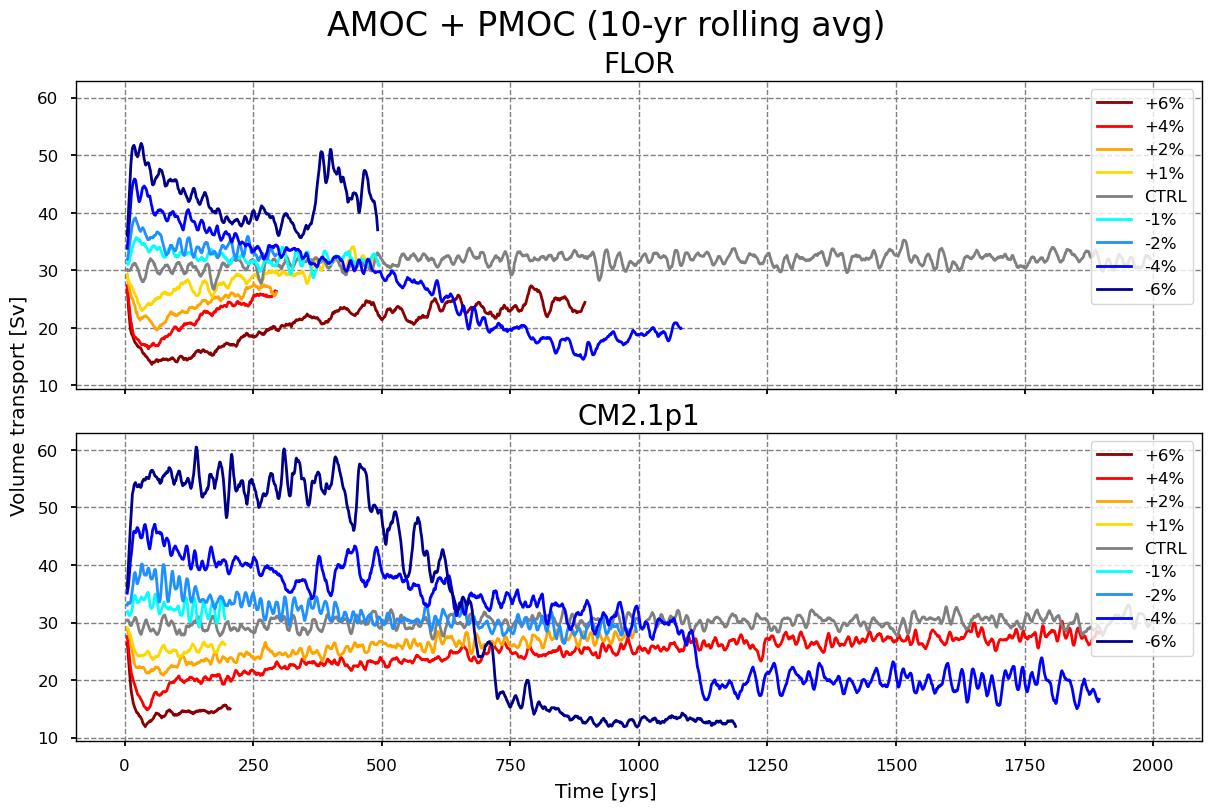

In [52]:
models = ['FLOR','CM2.1p1']
dir_in = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/'
basins = ['Atlantic','IndoPacific']

window = 10 # rolling avg (years)

plt.style.use('../func/paper.mplstyle')

fig, ax = plt.subplots(2, 1, figsize=(12,8), sharey = True, sharex=True)

for imodel in range(2):
    model = models[imodel]
    
    exps, extension = get_experiment_names(model)

    for iexp in range(np.size(exps)): # for each experiment
        
        experiment = exps[iexp]
        
        start_string = f'MOC_annavg_ts_Atlantic_{model}_{experiment}.' # find the file name based on the basin, experiment and model
        file_in = find_files_starting_with(dir_in, start_string)
        if np.size(file_in) == 0: # if no file exists
            continue
        AMOC = xr.open_dataarray(f'{dir_in}/{file_in}') # open the file

        start_string = f'MOC_annavg_ts_IndoPacific_{model}_{experiment}.' # find the file name based on the basin, experiment and model
        file_in = find_files_starting_with(dir_in, start_string)
        if np.size(file_in) == 0: # if no file exists
            continue
        PMOC = xr.open_dataarray(f'{dir_in}/{file_in}') # open the file

        MOC = AMOC + PMOC
        
        color, label = get_color_label(experiment)
        ax[imodel].plot(MOC.rolling(year=window,center=True).mean('year'),color=color,label=label) # plot timeseries

    ax[imodel].legend()
        
    ax[imodel].set_title(f'{model}')
    fig.suptitle(f'AMOC + PMOC ({window}-yr rolling avg)')
    fig.supylabel('Volume transport [Sv]')
    fig.supxlabel('Time [yrs]')
    for axis in ax.flatten():
        axis.grid('--')
            